In [1]:
import numpy as np
import pandas as pd

# 1. CONFIGURACIÓN INICIAL Y REPRODUCIBILIDAD ESTRICTA
np.random.seed(42)
n_samples = 20000

n_vip = int(n_samples * 0.15)
n_new = int(n_samples * 0.25)
n_risk = int(n_samples * 0.35)
n_loyal = n_samples - n_vip - n_new - n_risk

# 2. INYECCIÓN DE GEOMETRÍA CRUZADA (CONTRAPESOS DE VARIANZA)
recency_vip = np.random.exponential(scale=4, size=n_vip) + 1
frequency_vip = np.random.poisson(lam=32, size=n_vip) + 6
monetary_vip = np.random.normal(loc=980000, scale=95000, size=n_vip)

recency_new = np.random.uniform(low=1, high=14, size=n_new)
frequency_new = np.random.poisson(lam=2, size=n_new) + 1
monetary_new = np.random.normal(loc=42000, scale=8000, size=n_new)

recency_risk = np.random.normal(loc=160, scale=28, size=n_risk)
frequency_risk = np.random.poisson(lam=5, size=n_risk) + 1
monetary_risk = np.random.normal(loc=310000, scale=40000, size=n_risk)

recency_loyal = np.random.normal(loc=48, scale=12, size=n_loyal)
frequency_loyal = np.random.poisson(lam=16, size=n_loyal) + 2
monetary_loyal = np.random.normal(loc=540000, scale=70000, size=n_loyal)

# 3. CONSOLIDACIÓN Y TRATAMIENTO DE RANGOS REALISTAS
df = pd.DataFrame({
    'CustomerID': [f"ID_{100000 + i}" for i in range(n_samples)],
    'Recency': np.concatenate([recency_vip, recency_new, recency_risk, recency_loyal]),
    'Frequency': np.concatenate([frequency_vip, frequency_new, frequency_risk, frequency_loyal]),
    'Monetary': np.concatenate([monetary_vip, monetary_new, monetary_risk, monetary_loyal])
})

df['Recency'] = np.clip(df['Recency'].astype(int), 1, 365)
df['Frequency'] = np.clip(df['Frequency'].astype(int), 1, 120)
df['Monetary'] = np.clip(df['Monetary'].round(0), 5000, 2000000)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. EXPORTACIÓN DEL ARCHIVO CSV
df.to_csv('online_retail_rfm_20k.csv', index=False)
print(f"--> Dataset generado exitosamente: 'online_retail_rfm_20k.csv' ({df.shape[0]} filas).")

--> Dataset generado exitosamente: 'online_retail_rfm_20k.csv' (20000 filas).


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  20000 non-null  object 
 1   Recency     20000 non-null  int64  
 2   Frequency   20000 non-null  int64  
 3   Monetary    20000 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 625.1+ KB


In [3]:
df.describe().round(2)

,Recency,Frequency,Monetary
count,20000.00,20000.00,20000.00
mean,69.97,13.06,400628.15
std,69.59,12.38,305115.37
min,1.00,1.00,13737.00
25%,7.00,4.00,116494.00
50%,45.00,7.00,333030.00
75%,142.25,19.00,556323.25
max,264.00,58.00,1300851.00


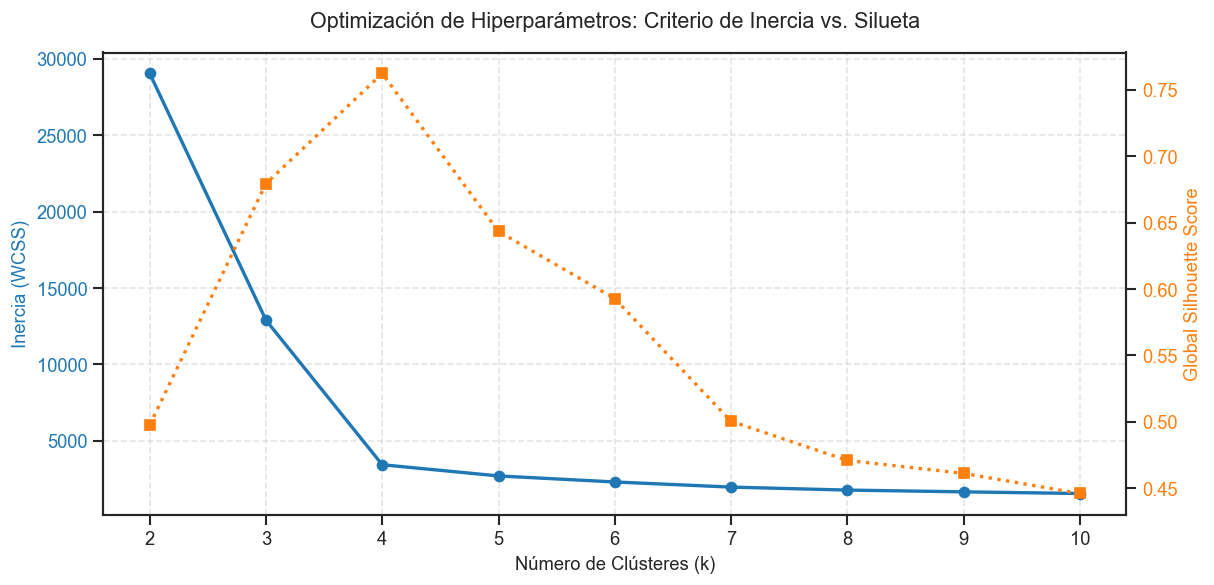

=== MÉTRICAS DE RENDIMIENTO DEL MODELO ===
Inercia Final (WCSS Global): 3,430.45
Coeficiente de Silueta Promedio Global: 0.7622

=== PERFILAMIENTO E INTERPRETACIÓN DE CENTROIDES ===
         Recency  Frequency   Monetary  Volume_Clientes  Pct_Clientes
Cluster                                                              
0           4.54      37.98  978761.54             3000         15.00
1         159.00       6.01  310200.52             6990         34.95
2           7.16       3.00   42119.91             5005         25.02
3          47.65      18.04  538894.42             5005         25.02




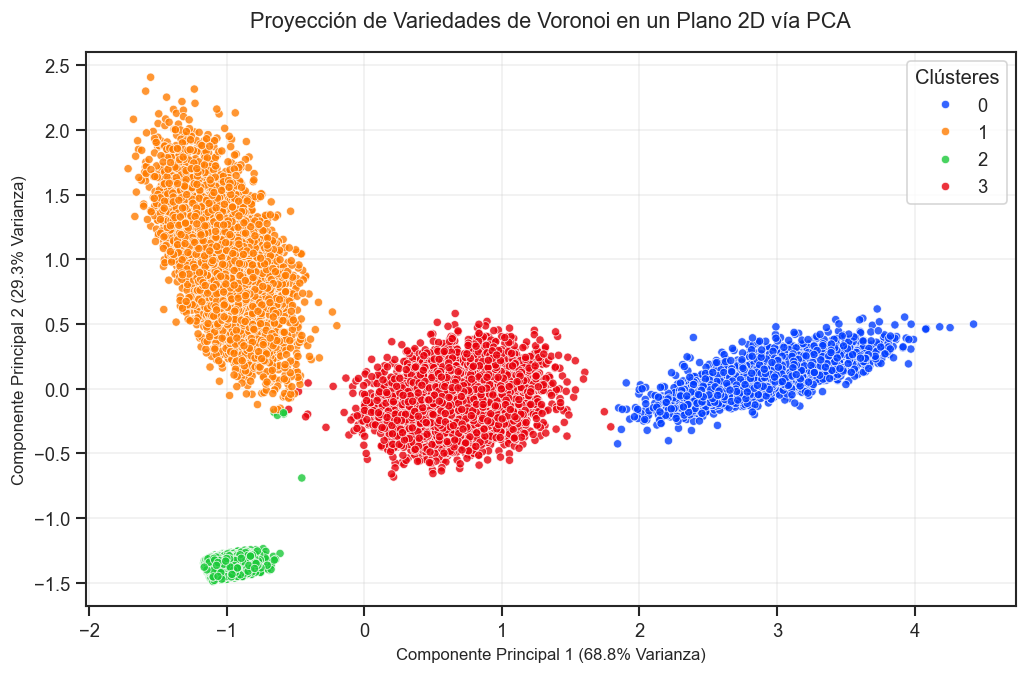

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Configurar el estilo base de Seaborn
sns.set_theme(style="ticks")

# =====================================================================
# 1. CARGA DE DATOS Y PRECONDICIÓN ALGEBRAICA (STANDARDIZATION)
# =====================================================================
# Cargar el dataset de 20,000 registros previamente generado
df_rfm = pd.read_csv("online_retail_rfm_20k.csv")
X_features = df_rfm[["Recency", "Frequency", "Monetary"]]

# Estandarización Z-score obligatoria para mitigar el sesgo de escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# =====================================================================
# 2. SELECCIÓN DE HIPERPARÁMETROS: CICLO ELBOW VS. SILHOUETTE
# =====================================================================
inertia_hist = []
silhouette_hist = []
k_range = range(2, 11)

# Bucle iterativo sobre el rango de k para evaluar métricas geométricas
for k in k_range:
    kmeans_eval = KMeans(
        n_clusters=k, init="k-means++", random_state=42, n_init=10
    )
    labels_eval = kmeans_eval.fit_predict(X_scaled)

    # WCSS (Inercia)
    inertia_hist.append(kmeans_eval.inertia_)
    # Coeficiente de Silueta Global
    silhouette_hist.append(silhouette_score(X_scaled, labels_eval))

# Visualización Dual de Curvas de Diagnóstico Matemático (Usando 'bright')
fig, ax1 = plt.subplots(figsize=(11, 5), dpi = 120)

color = "tab:blue"
ax1.set_xlabel("Número de Clústeres (k)", fontsize=11)
ax1.set_ylabel("Inercia (WCSS)", color=color, fontsize=11)
ax1.plot(k_range, inertia_hist, marker="o", color=color, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Global Silhouette Score", color=color, fontsize=11)
ax2.plot(
    k_range,
    silhouette_hist,
    marker="s",
    color=color,
    linewidth=2,
    linestyle=":",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Optimización de Hiperparámetros: Criterio de Inercia vs. Silueta",
    fontsize=13,
    pad=15,
)
plt.show()

# =====================================================================
# 3. ENTRENAMIENTO DEFINITIVO DEL MODELO OPTIMIZADO
# =====================================================================
# k=4 seleccionado mediante el análisis del codo e inflexión de silueta
k_opt = 4
final_kmeans = KMeans(
    n_clusters=k_opt, init="k-means++", random_state=42, n_init=10
)
df_rfm["Cluster"] = final_kmeans.fit_predict(X_scaled)

# =====================================================================
# 4. MEDIDAS DE DESEMPEÑO Y RESULTADOS GLOBAL DEL AJUSTE
# =====================================================================
inercia_final = final_kmeans.inertia_
silueta_final = silhouette_score(X_scaled, df_rfm["Cluster"])

print("=== MÉTRICAS DE RENDIMIENTO DEL MODELO ===")
print(f"Inercia Final (WCSS Global): {inercia_final:,.2f}")
print(f"Coeficiente de Silueta Promedio Global: {silueta_final:.4f}\n")

# =====================================================================
# 5. PERFILAMIENTO INVERSO (MÉTRICAS EN ESCALA ORIGINAL)
# =====================================================================
print("=== PERFILAMIENTO E INTERPRETACIÓN DE CENTROIDES ===")
profile = df_rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
profile["Volume_Clientes"] = df_rfm.groupby("Cluster")["CustomerID"].count()
profile["Pct_Clientes"] = (
    (profile["Volume_Clientes"] / len(df_rfm)) * 100
).round(2)
print(profile.round(2))
print("\n")

# =====================================================================
# 6. VISUALIZACIÓN EN SUBESPACIO REDUCIDO MEDIANTE PCA 2D ('bright')
# =====================================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df_rfm["Cluster"]

plt.figure(figsize=(10, 6), dpi = 120)

# Dibujar la nube de puntos usando la paleta vibrante 'bright' de Seaborn
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="bright",
    alpha=0.8,
    edgecolor="w",
    linewidth=0.5,
    s=25,
)

# Configuración de metadatos del gráfico
plt.title(
    "Proyección de Variedades de Voronoi en un Plano 2D vía PCA",
    fontsize=13,
    pad=15,
)
plt.xlabel(
    f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianza)",
    fontsize=10,
)
plt.ylabel(
    f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianza)",
    fontsize=10,
)
plt.grid(True, alpha=0.3)
plt.legend(title="Clústeres", loc="upper right")
plt.show()

In [5]:
df_pca

,PC1,PC2,Cluster
0,-1.605547,1.427737,1
1,2.045791,-0.162711,0
2,-1.121836,1.519148,1
3,3.204631,0.179394,0
4,-1.183498,1.277765,1
...,...,...,...
19995,-1.204518,1.083577,1
19996,-1.188399,1.189827,1
19997,-0.923680,-1.385587,2
19998,2.231337,-0.154973,0
